# Multiclass Classification

## Overview

Multiclass classification assigns observations to one of three or more mutually exclusive classes. Most sklearn classifiers support multiclass natively; some binary classifiers require a decomposition strategy.

**Decomposition strategies for binary-only classifiers:**

| Strategy | How | When |
|---|---|---|
| One-vs-Rest (OvR) | K binary classifiers, one per class | Default for most sklearn models |
| One-vs-One (OvO) | K*(K-1)/2 binary classifiers | SVM (default in sklearn) |

**Evaluation metrics extend to multiclass:**
- `macro` average: unweighted mean across classes (treats all classes equally)
- `weighted` average: weighted by class frequency
- Per-class precision, recall, F1
- Multiclass confusion matrix

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score)
from scipy.special import softmax

rng = np.random.default_rng(42)
n = 450
# Three catchment quality classes: poor, moderate, good
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
ph         = rng.normal(7.2, 0.5, n)
phosphorus = rng.gamma(1.5, 1.5, n)
# Score drives class: high score -> good
score = -0.003*elevation - 0.3*nitrate + 0.5*ph - 0.2*phosphorus
terciles = np.percentile(score, [33.3, 66.7])
label = np.digitize(score, terciles)  # 0=poor, 1=moderate, 2=good
class_names = ["poor","moderate","good"]
X = np.column_stack([elevation, nitrate, ph, phosphorus])
feat_names = ["elevation","nitrate","ph","phosphorus"]
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)
print(f"Class distribution: {np.bincount(label)}")

Class distribution: [150 150 150]


---
## Fitting and Per-Class Metrics

In [2]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(classification_report(y_te, rf.predict(X_te), target_names=class_names))
# Macro vs weighted averages
from sklearn.metrics import f1_score
f1_macro    = f1_score(y_te, rf.predict(X_te), average="macro")
f1_weighted = f1_score(y_te, rf.predict(X_te), average="weighted")
print(f"F1 macro={f1_macro:.3f}, weighted={f1_weighted:.3f}")
print("Use macro to treat all classes equally; weighted when class size matters.")

              precision    recall  f1-score   support

        poor       0.87      0.92      0.89        37
    moderate       0.82      0.71      0.76        38
        good       0.85      0.92      0.89        38

    accuracy                           0.85       113
   macro avg       0.85      0.85      0.85       113
weighted avg       0.85      0.85      0.85       113

F1 macro=0.847, weighted=0.847
Use macro to treat all classes equally; weighted when class size matters.


---
## Confusion Matrix

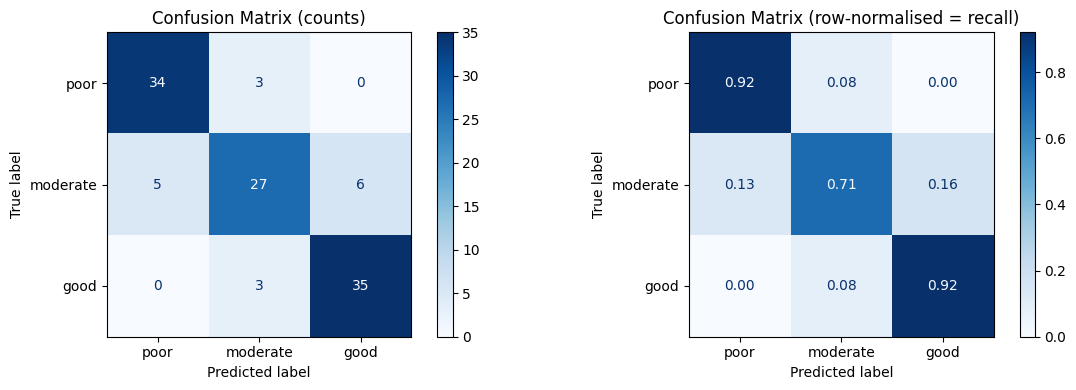

In [3]:
cm = confusion_matrix(y_te, rf.predict(X_te))
fig, axes = plt.subplots(1,2,figsize=(12,4))
# Raw counts
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)")
# Row-normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], cmap="Blues", values_format=".2f")
axes[1].set_title("Confusion Matrix (row-normalised = recall)")
plt.tight_layout(); plt.show()

---
## Multiclass ROC-AUC

OvR macro AUC: 0.959
OvO macro AUC: 0.959


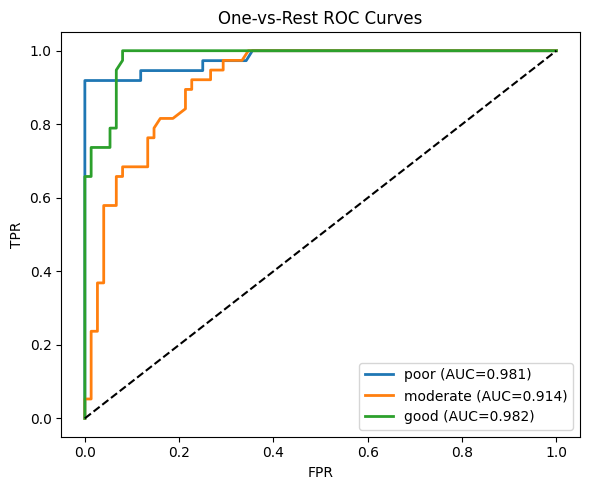

In [4]:
# One-vs-Rest AUC for each class + macro average
prob = rf.predict_proba(X_te)
auc_ovr = roc_auc_score(y_te, prob, multi_class="ovr", average="macro")
auc_ovo = roc_auc_score(y_te, prob, multi_class="ovo", average="macro")
print(f"OvR macro AUC: {auc_ovr:.3f}")
print(f"OvO macro AUC: {auc_ovo:.3f}")
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
y_te_bin = label_binarize(y_te, classes=[0,1,2])
fig, ax = plt.subplots(figsize=(6,5))
for i, cls in enumerate(class_names):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_te_bin[:,i], prob[:,i])
    auc_i = roc_auc_score(y_te_bin[:,i], prob[:,i])
    ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={auc_i:.3f})")
ax.plot([0,1],[0,1],"k--"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("One-vs-Rest ROC Curves"); ax.legend()
plt.tight_layout(); plt.show()

---
## Logistic Regression with OvR vs Multinomial

In [5]:
import inspect
for solver_multi in [("lbfgs","ovr"),("lbfgs","multinomial")]:
    solver, multi = solver_multi
    # prefer passing multi_class when the sklearn LogisticRegression supports it
    sig = inspect.signature(LogisticRegression)
    if 'multi_class' in sig.parameters:
        lr = LogisticRegression(solver=solver, multi_class=multi, max_iter=500)
    else:
        lr = LogisticRegression(solver=solver, max_iter=500)
        print(f"Warning: LogisticRegression() does not accept 'multi_class' — falling back to default for multi={multi}")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", lr)
    ])
    cv = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="f1_macro")
    print(f"LogReg multi_class={multi}: CV F1-macro={cv.mean():.3f} +/- {cv.std():.3f}")

LogReg multi_class=ovr: CV F1-macro=0.961 +/- 0.015
LogReg multi_class=multinomial: CV F1-macro=0.961 +/- 0.015


---

## Common Pitfalls

**1. Using macro-averaged F1 when class sizes are very unequal**  
Macro F1 treats each class equally regardless of size. A rare class with low F1 drags the macro average down substantially. Use weighted F1 when class sizes differ and all predictions matter, or report per-class metrics so readers can assess each class separately.

**2. Reading only the diagonal of the confusion matrix**  
Off-diagonal cells reveal systematic confusions between specific class pairs, which often point to feature engineering opportunities or meaningful class overlaps. Always examine which classes are confused with which.

**3. Not row-normalising the confusion matrix for imbalanced classes**  
Raw count confusion matrices hide recall differences when class sizes differ. Row-normalise to see recall (true positive rate) per class independently of class size.

**4. Using OvR for SVM without understanding OvO is the sklearn default**  
sklearn's SVC uses One-vs-One by default for multiclass. OvR is available but is a separate estimator. Check the documentation for each classifier to confirm which strategy is used.

**5. Not reporting per-class metrics for classes that matter most**  
In applied settings (rare species detection, disease diagnosis) the rare class performance matters most. Always break out precision, recall, and F1 per class and discuss the most critical classes explicitly, not just the macro average.
---
*python_methods_library - Samantha McGarrigle*